In [ ]:
Using Rioxarray to process Sentinel-2 data  - Single band

In [ ]:
## Table of Contents

1. [Import libraries](#1)<br>
2. [Read Landsat 8 data and stack them together using numpy.stack](#2)<br>
3. [Visualize bands](#3)<br>
4. [Raster map algebra](#4)<br>   
5. [Projections](#5)<br>    
    
</div>
<hr>

In [1]:
# Import necessary packages
import os

import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

import geopandas as gpd
import rioxarray as rxr
import xarray as xr

import earthpy as et
import earthpy.spatial as es
import earthpy.plot as ep


In [2]:
pth = r'C:\Users\Wenge\Dropbox (Hunter College)\data\EDS2022F\NYCimg\Sentinel-2\IMG_DATA'
dirpath= os.path.join(pth,'T18TWL_20210912T154911_B02.jp2')
b2 = rxr.open_rasterio(dirpath,masked=True)


In [5]:
# View the Coordinate Reference System (CRS) & spatial extent
print("The CRS for this data is:", b2.rio.crs)
print("The spatial extent is:", b2.rio.bounds())
# View no data value
print("The no data value is:", b2.rio.nodata)

The CRS for this data is: EPSG:32618
The spatial extent is: (499980.0, 4490220.0, 609780.0, 4600020.0)
The no data value is: None


In [3]:
print("the minimum raster value is: ", np.nanmin(b2.values))
print("the maximum raster value is: ", np.nanmax(b2.values))

the minimum raster value is:  0.0
the maximum raster value is:  24330.0


In [6]:
b2.shape

(1, 10980, 10980)

In [4]:
b2.rio.transform()

Affine(10.0, 0.0, 499980.0,
       0.0, -10.0, 4600020.0)

In [9]:
b2 = rxr.open_rasterio(dirpath, masked=True).squeeze()
b2.shape

(10980, 10980)

In [10]:
print("the minimum raster value is: ", np.nanmin(b2.values))
print("the maximum raster value is: ", np.nanmax(b2.values))

the minimum raster value is:  0.0
the maximum raster value is:  24330.0


(<Figure size 720x288 with 1 Axes>, <AxesSubplot:>)

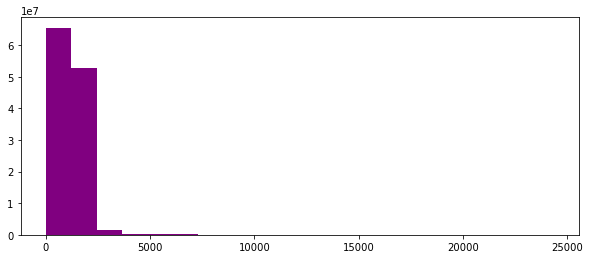

In [11]:
ep.hist(b2.values, figsize = (10, 4))

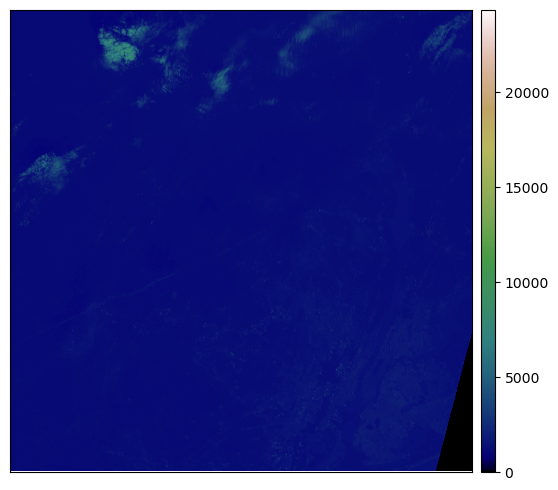

In [5]:
ep.plot_bands(b2.values, 
              cmap = 'gist_earth', 
              figsize = (10, 6), 
              cols = 1, 
              cbar = True)
plt.show()

## Subsetting

In [6]:
# Load vector layer 
from geodatasets import get_path # need to install geodatasets first
path_to_data = get_path('nybb')
nybb = gpd.read_file(path_to_data)

# nybb epsg
nybb.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US Survey feet)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [7]:
# clipping for NYBB area
b2_clipped = b2.rio.clip(nybb.geometry.apply(mapping), nybb.crs)
b2_clipped

<xarray.DataArray (band: 1, y: 3973, x: 4300)>
array([[[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan, 1363., 1269., ...,   nan,   nan,   nan],
        [1277., 1313., 1241., ...,   nan,   nan,   nan],
        [1278., 1259., 1238., ...,   nan,   nan,   nan]]], dtype=float32)
Coordinates:
  * band         (band) int32 1
  * x            (x) float64 5.668e+05 5.668e+05 ... 6.097e+05 6.098e+05
  * y            (y) float64 4.53e+06 4.53e+06 4.53e+06 ... 4.49e+06 4.49e+06
    spatial_ref  int32 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

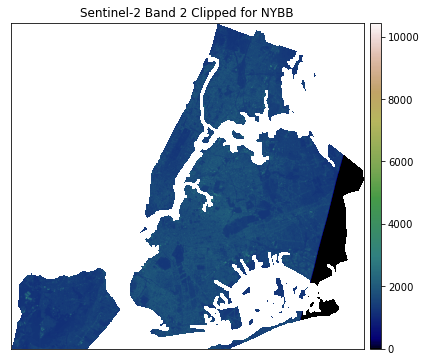

In [15]:
ep.plot_bands(b2_clipped.values, title='Sentinel-2 Band 2 Clipped for NYBB',
              cmap = 'gist_earth', 
              figsize = (10, 6), 
              cols = 1, 
              cbar = True)
plt.show()

In [10]:
# save into a geotiff file
# need to find a way to remove this file first
pth = 'sentinel2_b2.tif'
b2_clipped.rio.to_raster(pth)

C:\Users\Wenge\miniconda3\envs\geospatial\lib\site-packages\IPython\core\interactiveshell.py:3079: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  result = runner(coro)
C:\Users\Wenge\miniconda3\envs\geospatial\lib\site-packages\xarray\coding\variables.py:558: RuntimeWarning: invalid value encountered in cast
  data = data.astype(dtype=dtype)


In [11]:
b2_clipped = rxr.open_rasterio(pth, masked=True)
b2_clipped

<xarray.DataArray (band: 1, y: 3973, x: 4300)>
[17083900 values with dtype=float32]
Coordinates:
  * band         (band) int32 1
  * x            (x) float64 5.668e+05 5.668e+05 ... 6.097e+05 6.098e+05
  * y            (y) float64 4.53e+06 4.53e+06 4.53e+06 ... 4.49e+06 4.49e+06
    spatial_ref  int32 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

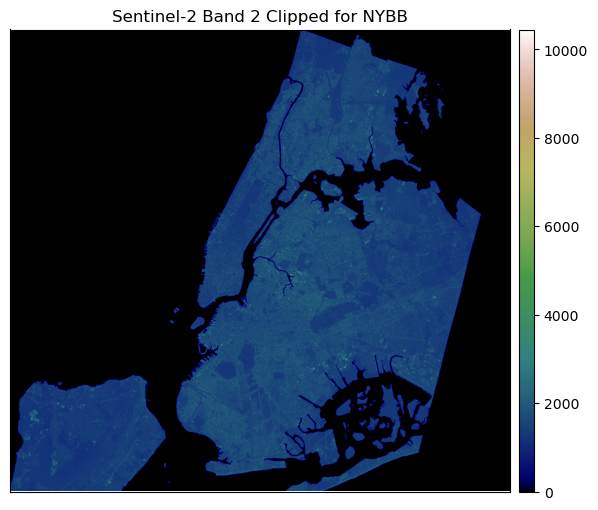

In [15]:
ep.plot_bands(b2_clipped.values, title='Sentinel-2 Band 2 Clipped for NYBB',
              cmap = 'gist_earth', 
              figsize = (10, 6), 
              cols = 1, 
              cbar = True)
plt.show()